In [20]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

Selecting one image

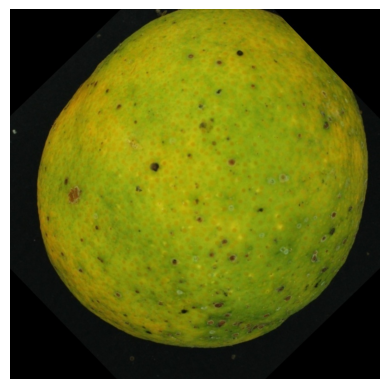

In [21]:
img_path = "../dataset/train/grenning/g (1).jpg"

img = cv2.imread(img_path)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

plt.imshow(img_rgb)

plt.axis("off")

plt.show()

Fruit segmentation

In [22]:
hsv = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2HSV
)

lower_orange = np.array(
    [5,50,50]
)

upper_orange = np.array(
    [30,255,255]
)

fruit_mask = cv2.inRange(

    hsv,

    lower_orange,

    upper_orange

)

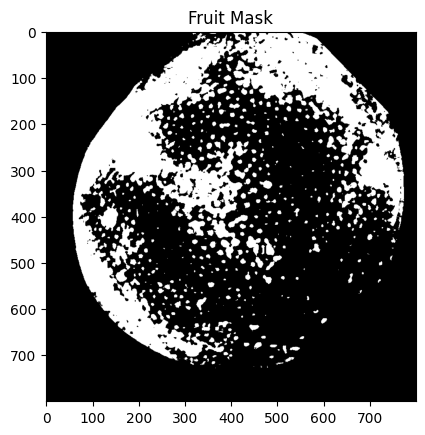

In [23]:
plt.imshow(
    fruit_mask,
    cmap='gray'
)

plt.title(
    "Fruit Mask"
)

plt.show()

Defect Segmentation

In [24]:
gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

_, defect_mask = cv2.threshold(

    gray,

    80,

    255,

    cv2.THRESH_BINARY_INV

)

In [25]:
defect_inside = cv2.bitwise_and(

    defect_mask,

    fruit_mask

)

Percentage Calculation

In [26]:
fruit_pixels = np.sum(
    fruit_mask>0
)

defect_pixels = np.sum(
    defect_inside>0
)

spoilage = (

    defect_pixels/

    fruit_pixels

)*100

print(

    f"Spoilage: {spoilage:.2f}%"

)

Spoilage: 3.28%
